<a href="https://colab.research.google.com/github/alfonsorinconbarrera/alfonsorinconbarrera/blob/main/Diagrama_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving agente_multirol.py to agente_multirol.py


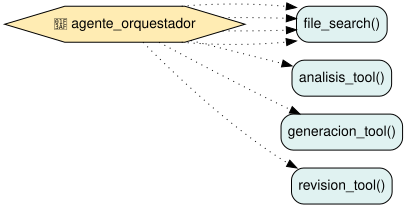

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Instalar Graphviz si no está
!pip install graphviz

import ast
from graphviz import Digraph
from IPython.display import SVG, display
from google.colab import files

# Subir script Python
uploaded = files.upload()
script_name = list(uploaded.keys())[0]

# Leer contenido
with open(script_name, "r", encoding="utf-8") as f:
    script_code = f.read()

# Analizar AST
tree = ast.parse(script_code)
orquestador = None
agentes = []
herramientas = []

for node in ast.walk(tree):
    # Buscar definición de agentes
    if isinstance(node, ast.Assign) and isinstance(node.value, ast.Call):
        if hasattr(node.value.func, 'id') and node.value.func.id == 'Agent':
            nombre_variable = node.targets[0].id
            nombre_agente = None
            tiene_handoffs = False
            tiene_tools = False
            for kw in node.value.keywords:
                if kw.arg == 'name':
                    nombre_agente = kw.value.s
                if kw.arg == 'handoffs':
                    tiene_handoffs = True
                    for h in kw.value.elts:
                        if isinstance(h, ast.Name):
                            agentes.append(h.id)
                if kw.arg == 'tools':
                    tiene_tools = True
                    for t in kw.value.elts:
                        if isinstance(t, ast.Call) and hasattr(t.func, 'attr') and t.func.attr == 'as_tool':
                            agentes.append(t.func.value.id)
                        elif isinstance(t, ast.Name):
                            herramientas.append(t.id)
            if tiene_handoffs or tiene_tools:
                orquestador = nombre_variable  # Detectar quién es el orquestador

# Crear el grafo
g = Digraph("SistemaOrquestador", format='svg')
g.attr(rankdir='LR', fontsize="12")

style_orquestador = {"shape": "hexagon", "style": "filled", "fillcolor": "#FFECB3", "fontname": "Helvetica"}
style_agente = {"shape": "ellipse", "style": "filled", "fillcolor": "#FFF3E0", "fontname": "Helvetica"}
style_tool = {"shape": "box", "style": "rounded,filled", "fillcolor": "#E0F2F1", "fontname": "Helvetica"}

# Nodo del orquestador
g.node(orquestador, f"🎯 {orquestador}", **style_orquestador)

# Agentes delegados (handoffs o as_tool)
for ag in agentes:
    g.node(ag, ag, **style_agente)
    g.edge(orquestador, ag, label="handoff / tool", style="solid")

# Herramientas simples
for tool in herramientas:
    g.node(tool, tool + "()", **style_tool)
    g.edge(orquestador, tool, style="dotted")

# Renderizar y mostrar
nombre_archivo = "diagrama_orquestador"
svg_path = g.render(nombre_archivo, view=False)
display(SVG(svg_path))
files.download(svg_path)
